In [3]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [20]:
with open('/lustre/scratch127/qpg/jc59/circuit_depths/results30.pkl', 'rb') as f:
    res = pickle.load(f)
for k, v in res.items():
    print(k, v['default'], v['rz'][0:3], v['rzz'])

test_N7_W3 (1911, 1678) (1543, 1000, 21) (1403, 920, 21)
test_N7_W4 (3125, 2555) (2553, 1357, 42) (2385, 1251, 42)
test_N7_W5 (4947, 4072) (4842, 2247, 207) (4606, 2102, 184)
test_N2_W2 (106, 95) (86, 73, 2) (74, 58, 1)
trivial (367, 325) (242, 182, 8) (212, 154, 8)
test_N3_W4 (610, 504) (383, 198, 5) (380, 204, 5)
test_N4_W5 (3716, 3081) (2985, 1436, 30) (2848, 1352, 30)
test_N4_W6 (4827, 3999) (5538, 2272, 111) (5997, 2172, 194)
test_N5_W6 (6645, 5194) (7255, 3076, 138) (7254, 2876, 194)
test_N7_W2 (815, 752) (679, 543, 14) (664, 529, 14)
test_N8_W2 (3512, 3118) (3575, 2800, 25) (3274, 2480, 25)
test_N8_W3 (6992, 6073) (6692, 4607, 71) (6315, 4316, 71)
test_N8_W4 (9105, 7717) (9366, 4737, 115) (8553, 4357, 115)
test_N8_W5 (14494, 12104) (15737, 6545, 248) (14675, 6030, 248)
test_N8_W6 (18857, 15511) (27090, 11109, 342) (26383, 10533, 385)
test_N9_W6 (29590, 23636) (44243, 20662, 171) (43402, 20309, 171)
test_N10_W6 (25025, 20615) (35515, 15311, 385) (34480, 14612, 385)
test_N14_W7 (3

In [32]:
with open('/lustre/scratch127/qpg/jc59/circuit_depths/results.precompute.120.pkl', 'rb') as f:
    res = pickle.load(f)
for k, v in res.items():
    print(k, v['default'][::-1], v['rz'][0:3]) #, v['rzz'])

test_N4_W6 (4039, 4882) [1712, 4109, 52]
test_N2_W2 (95, 106) [63, 90, 1]
trivial (305, 360) [175, 250, 8]


In [31]:
with open('/lustre/scratch127/qpg/jc59/circuit_depths/results.all2all.precompute.0.pkl', 'rb') as f:
    res = pickle.load(f)
for k, v in res.items():
    print(k, v['default'][::-1], v['rz'][0:3]) #, v['rzz'])

test_N2_W2 (67, 73) [46, 62, 0]
trivial (188, 209) [129, 198, 0]
test_N3_W4 (287, 331) [171, 329, 0]
test_N4_W5 (1720, 1829) [932, 2074, 0]
test_N4_W6 (2193, 2363) [1024, 2742, 0]
test_N5_W6 (2799, 3276) [1319, 3585, 0]
test_N7_W2 (436, 451) [387, 494, 0]
test_N7_W3 (941, 1002) [661, 1109, 0]
test_N7_W4 (1407, 1563) [863, 1783, 0]
test_N7_W5 (2133, 2427) [1246, 2695, 0]
test_N8_W2 (1672, 1695) [1346, 1869, 0]
test_N8_W3 (3342, 3408) [2665, 4226, 0]
test_N8_W4 (4237, 4359) [2553, 5263, 0]
test_N8_W5 (6516, 6706) [3550, 8183, 0]


In [30]:
qc = res['test_N3_W4']['rz'][4]
print(qc.count_ops())

OrderedDict([('cx', 370), ('rz', 150), ('swap', 25)])


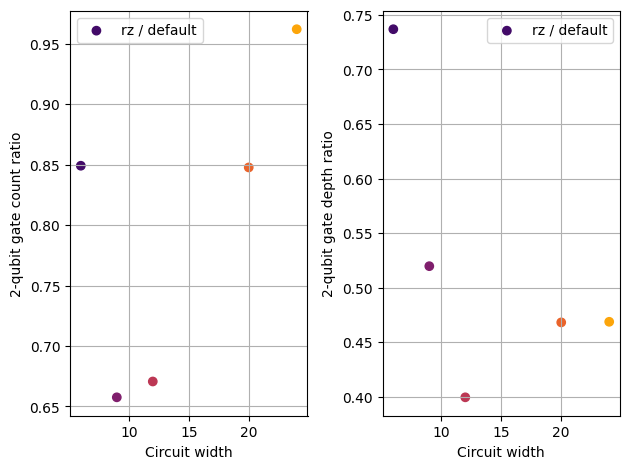

In [24]:
qubits = [ 6, 9, 12, 20, 24] #, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30] #, 35]

cmap = plt.get_cmap('inferno')

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        # 'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
        # 'test_N7_W4', 'test_N7_W5', 
        # 'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 
        # 'test_N8_W6', 'test_N9_W6', 'test_N10_W6' #,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    # rzz_depths.append(res[filename]['rzz'][1])
    # rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][0])
    rz_counts.append(res[filename]['rz'][1])

# zipped = zip(qubits, default_depths, default_counts, rzz_depths, rzz_counts, rz_depths, rz_counts)
# zipped = sorted(zipped)
# qubits, default_depths, default_counts, rzz_depths, rzz_counts, rz_depths, rz_counts = zip(*zipped)

default_counts = np.array(default_counts)
rz_counts = np.array(rz_counts)
# rzz_counts = np.array(rzz_counts)

default_depths = np.array(default_depths)
rz_depths = np.array(rz_depths)
# rzz_depths = np.array(rzz_depths)

colours = cmap(np.linspace(0.2, 0.8, len(rz_depths)))
fig, axes = plt.subplots(1, 2)
# axes[0].set_yscale('log')
axes[0].scatter(qubits, rz_counts / default_counts, marker='o', c = colours, label='rz / default')
# axes[0].scatter(qubits, rzz_counts / default_counts, marker='x', c = colours, label='rzz / default')
axes[0].legend()

plot_qubits = sorted(list(set(qubits)))
# p_counts_rz = np.polynomial.polynomial.Polynomial.fit(qubits, rz_counts / default_counts, 2)
# axes[0].plot(plot_qubits, p_counts_rz(plot_qubits))
# p_counts_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, rzz_counts / default_counts, 2)
# axes[0].plot(plot_qubits, p_counts_rzz(plot_qubits))

# axes[1].set_yscale('log')


axes[1].scatter(qubits, rz_depths / default_depths, marker='o', c = colours, label='rz / default')
# axes[1].scatter(qubits, rzz_depths / default_depths, marker='x', c = colours, label='rzz / default')
axes[1].legend()

# plot_qubits = sorted(list(set(qubits)))
# p_depths_rz = np.polynomial.polynomial.Polynomial.fit(qubits, rz_depths / default_depths, 2)
# axes[1].plot(plot_qubits, p_depths_rz(plot_qubits))
# p_depths_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, rzz_depths / default_depths, 2)
# axes[1].plot(plot_qubits, p_depths_rzz(plot_qubits))


axes[0].set_ylabel('2-qubit gate count ratio')
axes[0].set_xlabel('Circuit width')
axes[1].set_ylabel('2-qubit gate depth ratio')
axes[1].set_xlabel('Circuit width')
axes[0].grid()
axes[1].grid()


fig.tight_layout()
fig.show()

In [5]:
# qubits = [ 6, 9, 12, 20, 24, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30] #, 35]
qubits = [ 6, 9, 12, 20, 24, 8, 12, 16, 10, 15, 25] #, 30] #, 35]

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

# for filename in [
#         'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
#         'test_N4_W6', 
#         'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
#         'test_N7_W4', 'test_N7_W5', 
#         'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 'test_N8_W6',
#         'test_N9_W6', 'test_N10_W6'# ,'test_N14_W7'
# ]:
for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        # 'test_N5_W6', 
        'test_N7_W2', 'test_N7_W3',
        'test_N7_W4', 
        # 'test_N7_W5', 
        'test_N8_W2', 'test_N8_W3',
        # 'test_N8_W4', 
        'test_N8_W5', 
        # 'test_N8_W6', 'test_N9_W6', 'test_N10_W6' ,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    rzz_depths.append(res[filename]['rzz'][1])
    rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][1])
    rz_counts.append(res[filename]['rz'][0])

[array([7.3292361]), np.int32(2), array([1.09409246, 0.8960813 ]), np.float64(2.4424906541753444e-15)]


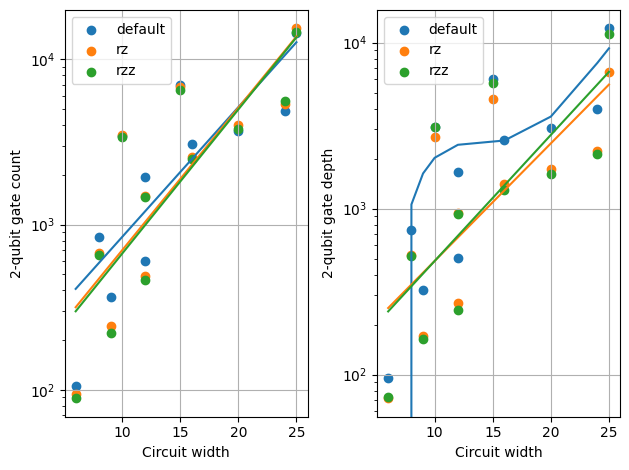

In [6]:
fig, axes = plt.subplots(1, 2)
axes[0].set_yscale('log')
axes[0].scatter(qubits, default_counts, label='default')
axes[0].scatter(qubits, rz_counts, label='rz')
axes[0].scatter(qubits, rzz_counts, label='rzz')
axes[0].legend()

plot_qubits = sorted(list(set(qubits)))
p_counts_default, full = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(default_counts), 1, full=True)
axes[0].plot(plot_qubits, np.exp(p_counts_default(plot_qubits)))
print(full)

p_counts_rz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rz_counts), 1)
axes[0].plot(plot_qubits, np.exp(p_counts_rz(plot_qubits)))

p_counts_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rzz_counts), 1)
axes[0].plot(plot_qubits, np.exp(p_counts_rzz(plot_qubits)))

axes[1].set_yscale('log')
axes[1].scatter(qubits, default_depths, label='default')
axes[1].scatter(qubits, rz_depths, label='rz')
axes[1].scatter(qubits, rzz_depths, label='rzz')
axes[1].legend()

plot_qubits = sorted(list(set(qubits)))
p_depths_default = np.polynomial.polynomial.Polynomial.fit(qubits, default_depths, 3)
axes[1].plot(plot_qubits, p_depths_default(plot_qubits))

p_depths_rz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rz_depths), 1)
axes[1].plot(plot_qubits, np.exp(p_depths_rz(plot_qubits)))

p_depths_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rzz_depths), 1)
axes[1].plot(plot_qubits, np.exp(p_depths_rzz(plot_qubits)))


axes[0].set_ylabel('2-qubit gate count')
axes[0].set_xlabel('Circuit width')
axes[1].set_ylabel('2-qubit gate depth')
axes[1].set_xlabel('Circuit width')
axes[0].grid()
axes[1].grid()


fig.tight_layout()
fig.show()

In [44]:
qubits = [ 6, 9, 12, 20, 24, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30, 35]
n = [2,3,3,4,4,4,4,4,4,4,5,5,5,5,5,5,5]
T = [2,3,4,5,6,6,2,3,4,5,2,3,4,5,6,6,6]

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
        'test_N7_W4', 'test_N7_W5', 
        'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 'test_N8_W6',
        'test_N9_W6', 'test_N10_W6' #,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    rzz_depths.append(res[filename]['rzz'][1])
    rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][1])
    rz_counts.append(res[filename]['rz'][0])
    


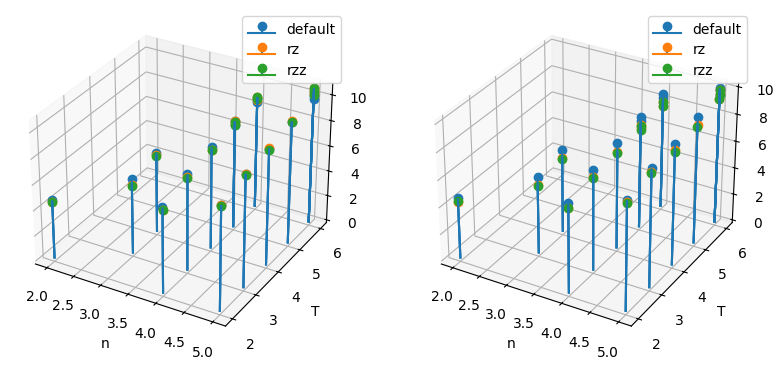

In [36]:
# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.set_ylabel('T')
ax.set_xlabel('n')
ax.grid()
# ax.set_zlim(50, 20000)
# ax.set_zscale('log')
markerline, stemlines, baseline = ax.stem(n, T, np.log(default_counts), label='default', basefmt='')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rz_counts), label='rz', markerfmt='C1o', linefmt='C0-', basefmt='C1-')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rzz_counts), label='rzz', markerfmt='C2o', linefmt='C0-', basefmt='C2-')
baseline.remove()

ax.legend()

# ==============
# Second subplot
# ==============
# set up the Axes for the second plot
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.set_ylabel('T')
ax.set_xlabel('n')
# ax.set_zlim(50, 20000)
# ax.set_zscale('log')

markerline, stemlines, baseline = ax.stem(n, T, np.log(default_depths), label='default', basefmt='')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rz_depths), label='rz', markerfmt='C1o', linefmt='C0-', basefmt='C1-')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rzz_depths), label='rzz', markerfmt='C2o', linefmt='C0-', basefmt='C2-')
baseline.remove()
ax.legend()
plt.show()

